# Регуляризация линейной регрессии. Практическая работа

## Цель практической работы

Научиться строить модель линейной регрессии с регуляризацией на реальных данных.

## Что входит в практическую работу

1. Загрузить данные и ознакомиться с ними.
2. Изучить данные и провести анализ, сконструировать новые признаки.
3. Разделить данные на обучающую и тестовую выборки.
4. Реализовать построение модели с помощью библиотеки Scikit-learn.
5. Подобрать коэффициенты регуляризации.
6. Получить качество модели с помощью MSE, MAE, $R^2$.
7. Ответить на вопросы в конце блокнота.

## Что оценивается 

- Выполнены все этапы работы.
- Подобраны коэффициенты регуляризации.
- Сделан вывод по результатам.
- Модель не переобучена.
- Получена модель хорошего качества.
- Сделаны выводы в конце блокнота.

## Как отправить работу на проверку

Скачайте файл с заданиями в материалах, откройте его через Jupyter Notebook и выполните задания.

## Задача

С набором данных вы уже знакомы из прошлого модуля — это данные по продажам домов. В этот раз признаков будет чуть больше, чтобы вам было интереснее. Краткое описание признаков:

* **LotArea** — размер участка в квадратных футах.
* **LotArea_M** — размер участка в квадратных метрах.
* **Street** — тип доступа к дороге.
* **BldgType** — тип жилья.
* **OverallQual** — общее качество материала и отделки.
* **OverallCond** — общая оценка состояния.
* **YearBuilt** — первоначальная дата постройки.
* **YearRemodAdd** — дата реконструкции.
* **RoofStyle** — тип крыши.
* **ExterQual** — качество материалов снаружи.
* **ExterCond** — текущее состояние материалов снаружи.
* **Foundation** — тип фундамента.
* **TotalBsmtSF** — общая площадь подвала в квадратных футах.
* **TotalBsmtSF_M** — общая площадь подвала в квадратных метрах.
* **Heating** — тип отопления.
* **HeatingQC** — качество и состояние отопления.
* **CentralAir** — кондиционирование.
* **GrLivArea** — жилая площадь в квадратных футах.
* **GrLivArea_M** — жилая площадь в квадратных метрах.
* **Bath** — количество ванных комнат.
* **KitchenQual** — качество кухни.
* **GarageArea** — площадь гаража в квадратных футах.
* **GarageArea_M** — площадь гаража в квадратных метрах.
* **DateSold** — месяц и год продажи.
* **SaleCondition** — условия сделки.
* **SalePrice** — стоимость продажи в долларах. Это целевая переменная, которую нам нужно предсказать.

Постройте модель линейной регрессии на этих данных. Проверьте качество модели на обучающей и тестовой выборках с помощью MAE, MSE, $R^2$. Определите, что модель не переобучилась.

## Задание 1 

Подключите необходимые библиотеки.

In [32]:
### Ваш код здесь ###
import pandas as pd 

from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## Задание 2

Считайте данные и посмотрите на несколько строк.

In [2]:
### Ваш код здесь ###
df = pd.read_csv('data.csv')
df

,LotArea,LotArea_M,Street,BldgType,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,ExterQual,...,CentralAir,GrLivArea,GrLivArea_M,Bath,KitchenQual,GarageArea,GarageArea_M,DateSold,SaleCondition,SalePrice
0,8450,785.030350,Pave,1Fam,7,5,2003,2003,Gable,Gd,...,Y,1710,158.864130,3,Gd,548,50.910844,2/2008,Normal,208500
1,9600,891.868800,Pave,1Fam,6,8,1976,1976,Gable,TA,...,Y,1262,117.243586,2,TA,460,42.735380,5/2007,Normal,181500
2,11250,1045.158750,Pave,1Fam,7,5,2001,2002,Gable,Gd,...,Y,1786,165.924758,3,Gd,608,56.485024,9/2008,Normal,223500
3,9550,887.223650,Pave,1Fam,7,5,1915,1970,Gable,TA,...,Y,1717,159.514451,1,Gd,642,59.643726,2/2006,Abnorml,140000
4,14260,1324.796780,Pave,1Fam,8,5,2000,2000,Gable,Gd,...,Y,2198,204.200794,3,Gd,836,77.666908,12/2008,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,735.513051,Pave,1Fam,6,5,1999,2000,Gable,TA,...,Y,1647,153.011241,3,TA,460,42.735380,8/2007,Normal,175000
1456,13175,1223.997025,Pave,1Fam,6,6,1978,1988,Gable,TA,...,Y,2073,192.587919,2,TA,500,46.451500,2/2010,Normal,210000
1457,9042,840.028926,Pave,1Fam,7,9,1941,2006,Gable,Ex,...,Y,2340,217.393020,2,Gd,252,23.411556,5/2010,Normal,266500
1458,9717,902.738451,Pave,1Fam,5,6,1950,1996,Hip,TA,...,Y,1078,100.149434,1,Gd,240,22.296720,4/2010,Normal,142125


## Задание 3 

Проведите разведочный анализ:

1. Выведите описательные статистики для числовых признаков.

In [3]:
### Ваш код здесь ###
df.describe()

,LotArea,LotArea_M,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,TotalBsmtSF_M,GrLivArea,GrLivArea_M,Bath,GarageArea,GarageArea_M,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,977.044879,6.099315,5.575342,1971.267808,1984.865753,1057.429452,98.238368,1515.463699,140.791124,1.947945,472.980137,43.941274,180921.195890
std,9981.264932,927.289456,1.382997,1.112799,30.202904,20.645407,438.705324,40.757041,525.480383,48.818704,0.794965,213.804841,19.863111,79442.502883
min,1300.000000,120.773900,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,334.000000,31.029602,0.000000,0.000000,0.000000,34900.000000
25%,7553.500000,701.742811,5.000000,5.000000,1954.000000,1967.000000,795.750000,73.927562,1129.500000,104.933938,1.000000,334.500000,31.076054,129975.000000
50%,9478.500000,880.581085,6.000000,5.000000,1973.000000,1994.000000,991.500000,92.113325,1464.000000,136.009992,2.000000,480.000000,44.593440,163000.000000
75%,11601.500000,1077.814155,7.000000,6.000000,2000.000000,2004.000000,1298.250000,120.611320,1776.750000,165.065405,3.000000,576.000000,53.512128,214000.000000
max,215245.000000,19996.906235,10.000000,9.000000,2010.000000,2010.000000,6110.000000,567.637330,5642.000000,524.158726,4.000000,1418.000000,131.736454,755000.000000


2. Постройте матрицу корреляций числовых признаков. Удалите линейно-зависимые признаки из данных.

C:\Users\Антон\AppData\Local\Temp\ipykernel_932\18222300.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  columns = df.corr().columns.tolist()
C:\Users\Антон\AppData\Local\Temp\ipykernel_932\18222300.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  plt.imshow(df.corr())


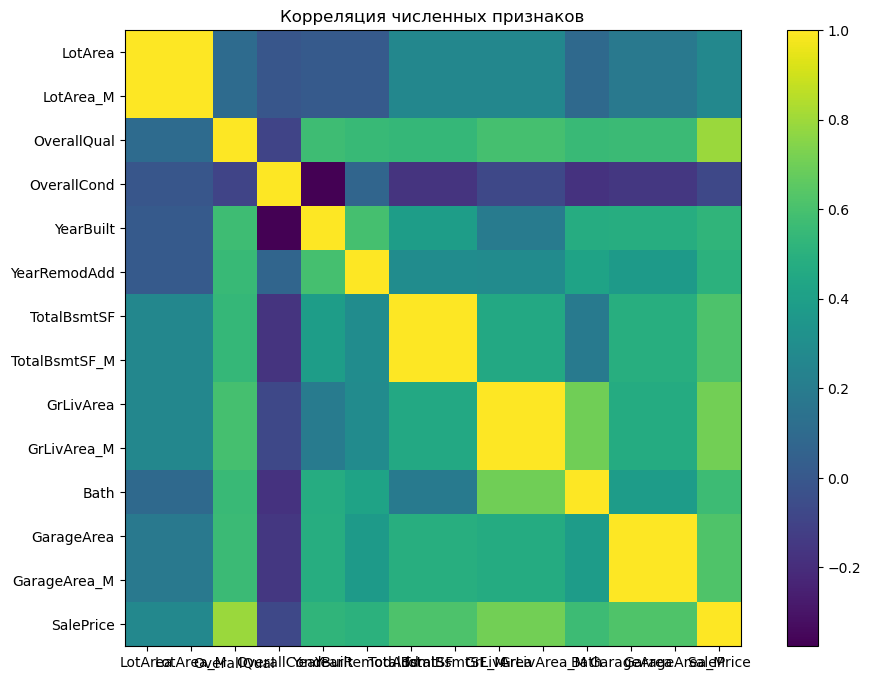

In [4]:
### Ваш код здесь ###
plt.figure(figsize=(12, 8))

columns = df.corr().columns.tolist()
plt.imshow(df.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

3. Посмотрите на индивидуальные графики зависимости целевой функции и отдельной переменной.

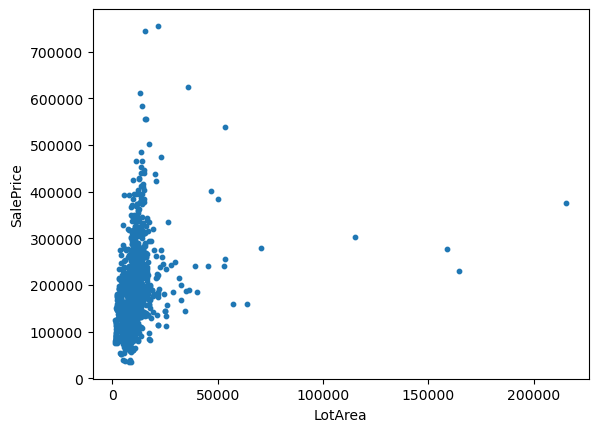

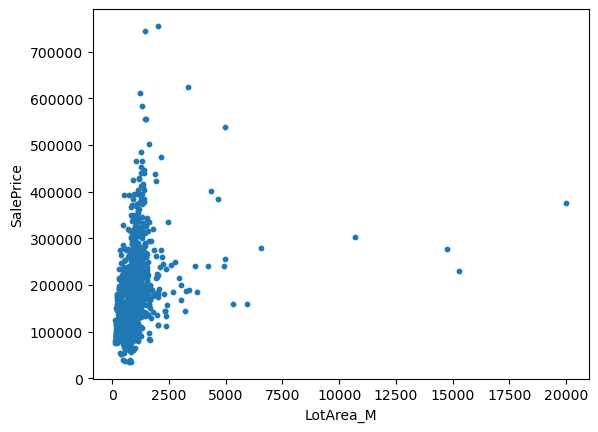

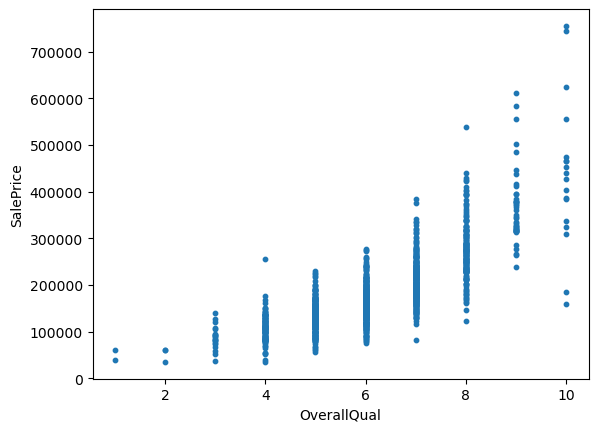

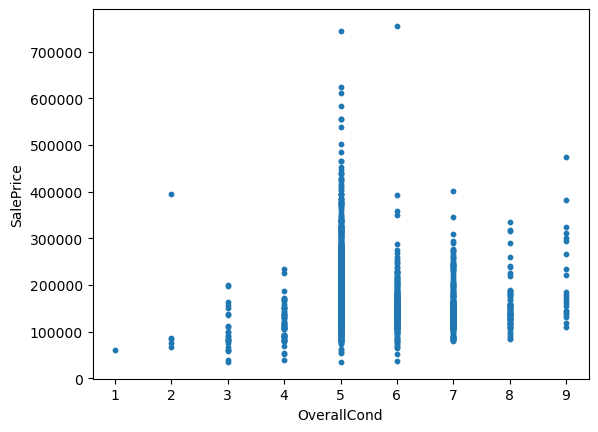

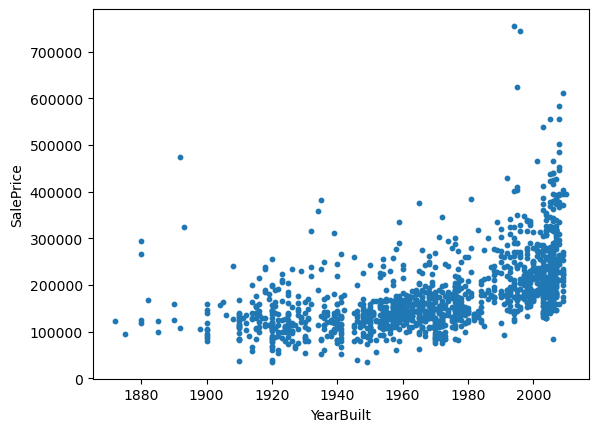

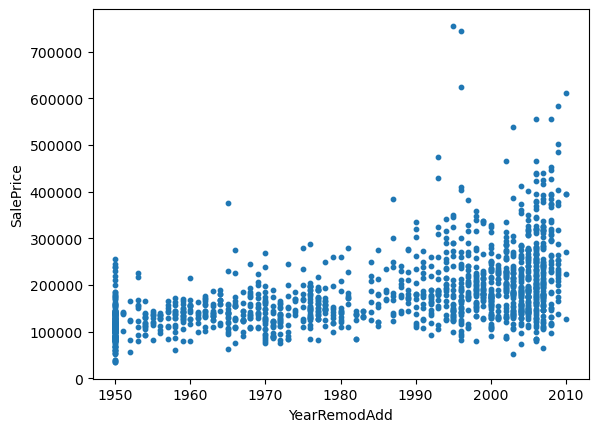

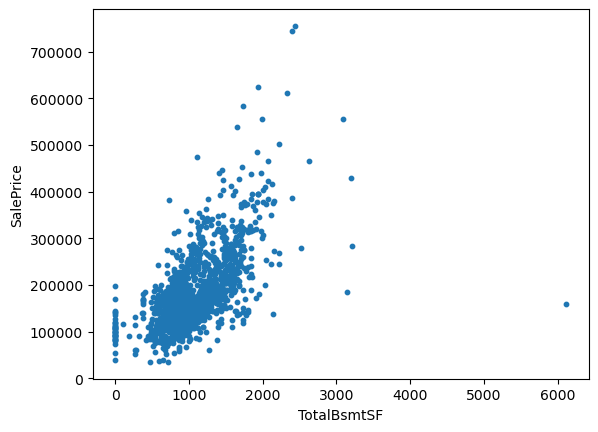

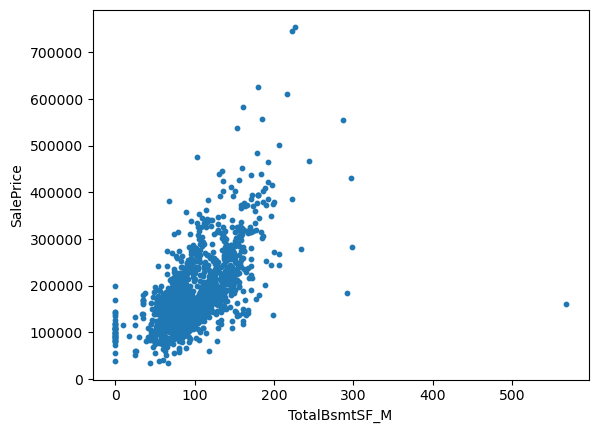

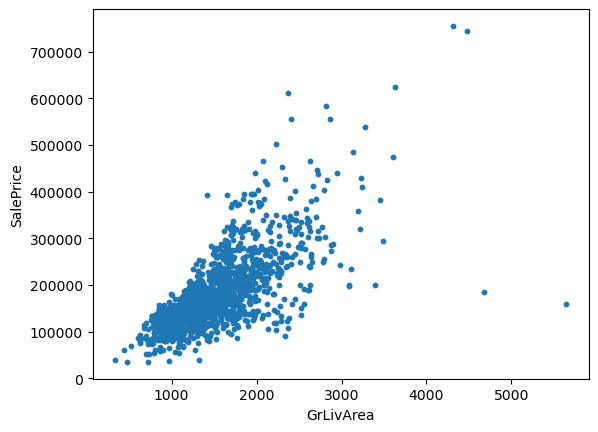

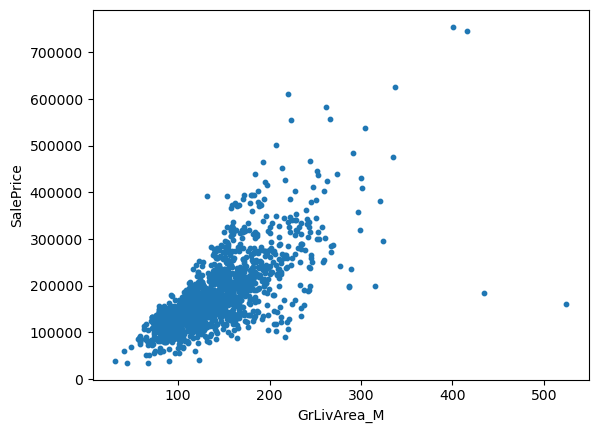

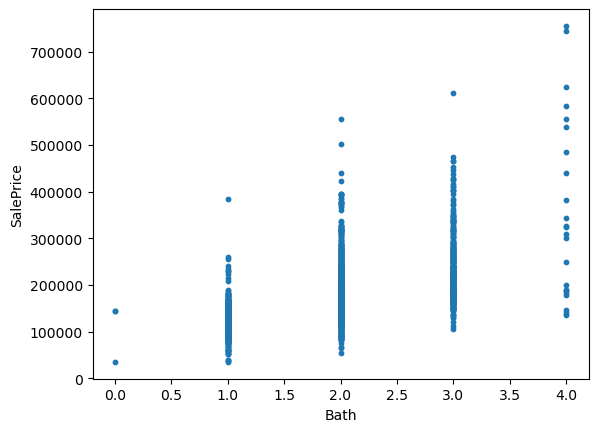

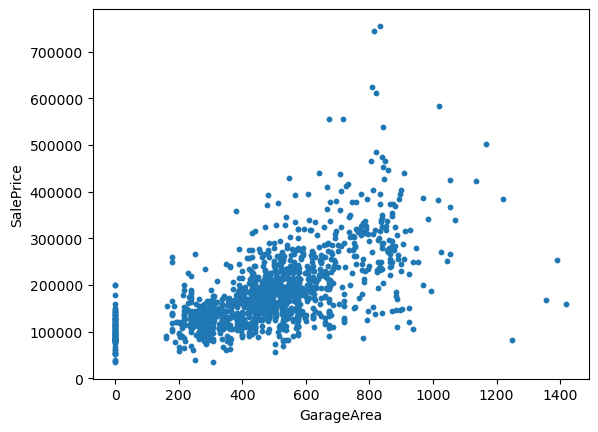

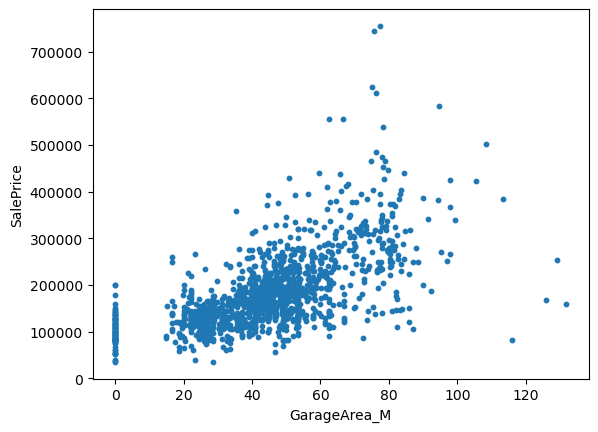

In [5]:
### Ваш код здесь ###
X = df.drop(['SalePrice'], axis=1)
y = df['SalePrice']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

for elem in numerical_features:
    plt.scatter(X[elem], y, s=10)
    #df = df.sort_values('x')
    plt.xlabel(elem)
    plt.ylabel('SalePrice')
    plt.show()
    

4. Сделайте предварительные выводы.

5. Создайте дополнительные переменные из уже имеющихся, обоснуйте свои решения.

In [6]:
### Ваш код здесь ###

#удаляем дублирующие признаки
df_new = df.drop(['LotArea','TotalBsmtSF', 'GrLivArea', 'GarageArea'], axis=1)

#генерируем новые фичи
#TotalBsmtSF_M_GrLivArea_M - соотношение общей площади подвала к жилой площади.
#LotAreaM_GarageArea_M - отношение размера участка к площади гаража.
#Bath_GrLivArea_M - количество ванных комнат на жилую площадь.
#LotAreaM_TotalBsmtSF_M - доля общей площади подвала в общем размере участка.

def calculate_proport(A, B):
  if B > 0:
    return A / B
  else:
    return 0

df_new['TotalBsmtSF_M_GrLivArea_M'] = df_new.apply(lambda x: calculate_proport(x['TotalBsmtSF_M'], x['GrLivArea_M']),axis=1)
df_new['LotAreaM_GarageArea_M'] = df_new.apply(lambda x: calculate_proport(x['LotArea_M'], x['GarageArea_M']), axis=1)
df_new['Bath_GrLivArea_M'] = df_new.apply(lambda x: calculate_proport(x['TotalBsmtSF_M'], x['GrLivArea_M']),axis=1)
df_new['LotAreaM_TotalBsmtSF_M'] = df_new.apply(lambda x: calculate_proport(x['LotArea_M'], x['TotalBsmtSF_M']),axis=1)



C:\Users\Антон\AppData\Local\Temp\ipykernel_932\1891130318.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  columns = df_new.corr().columns.tolist()
C:\Users\Антон\AppData\Local\Temp\ipykernel_932\1891130318.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  plt.imshow(df_new.corr())


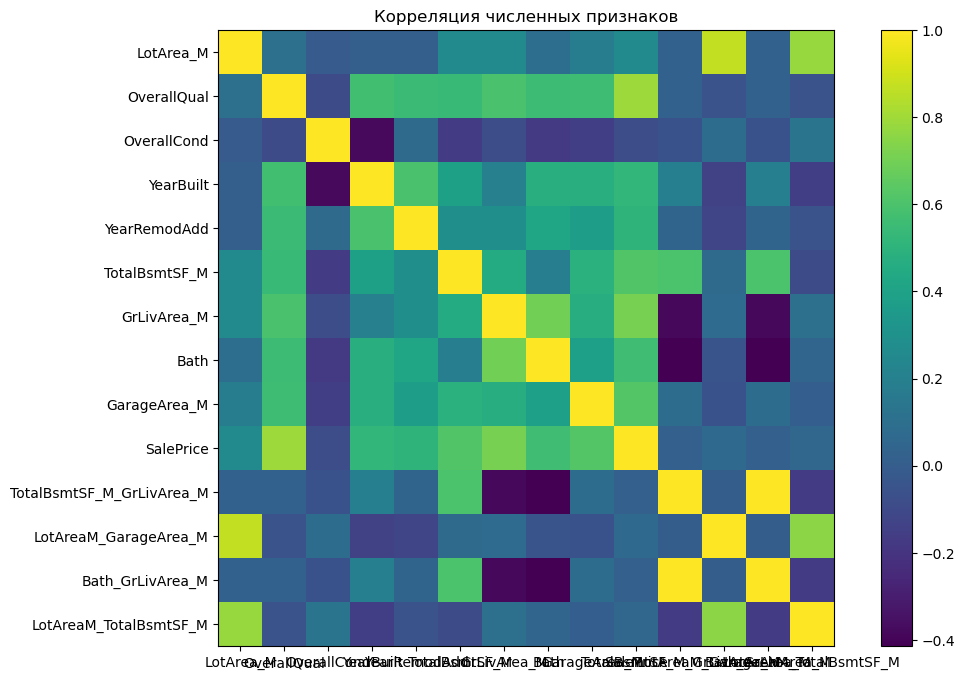

In [7]:
#Проверим зависимость целевой переменной от новых признаков
plt.figure(figsize=(12, 8))

columns = df_new.corr().columns.tolist()
plt.imshow(df_new.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

In [8]:
# Зависимость есть, оставляем эти признаки

## Задание 4 

Подготовьте данные:

1. Разделите данные на тренировочную и тестовую выборки.

In [9]:
### Ваш код здесь ###

2. Закодируйте категориальные признаки в тренировочной и тестовой выборках.

In [10]:
### Ваш код здесь ###

3. Подготовьте числовые признаки в тренировочной и тестовой выборках к передаче в модель: приведите их к единому масштабу.

In [11]:
### Ваш код здесь ###

In [12]:
X = df_new.drop(['SalePrice'], axis=1)
y = df_new['SalePrice']

categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

df_cat = pd.get_dummies(X[categorical_features], prefix=categorical_features)

d = preprocessing.normalize(X[numerical_features], axis=0)
df_num = pd.DataFrame(d, columns=numerical_features)

X = pd.concat([df_num, df_cat], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=63)

## Задание 5

Займитесь обучением модели:

1. Обучите модель линейной регрессии без регуляризации. Посмотрите на веса полученной модели. Сделайте предсказания по обучающей и тестовой выборкам.

In [20]:
### Ваш код здесь ###
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

LinearRegression()

In [27]:
# коэффициенты модели
print('w_0:', linear_regression.intercept_)
coef = list(linear_regression.coef_)
for i in range(len(coef)):
  print(f'w_{i+1}:', coef[i], X_train.columns[i])

w_0: -2.5678799815331795e+17
w_1: 183110.83555606796 LotArea_M
w_2: 4131370.931571822 OverallQual
w_3: 1437779.4168401072 OverallCond
w_4: 22598126.417399682 YearBuilt
w_5: 1564433.6331373842 YearRemodAdd
w_6: -4174589.908500169 TotalBsmtSF_M
w_7: 6807246.049130247 GrLivArea_M
w_8: 200937.0371519287 Bath
w_9: 526871.4656134311 GarageArea_M
w_10: 4.3313957485289824e+17 TotalBsmtSF_M_GrLivArea_M
w_11: 746075.8077770835 LotAreaM_GarageArea_M
w_12: -4.331395748478081e+17 Bath_GrLivArea_M
w_13: -243187.20534114604 LotAreaM_TotalBsmtSF_M
w_14: -3.074650333757589e+18 Street_Grvl
w_15: -3.074650333757577e+18 Street_Pave
w_16: 7.296059820725541e+17 BldgType_1Fam
w_17: 7.296059820725868e+17 BldgType_2fmCon
w_18: 7.2960598207255e+17 BldgType_Duplex
w_19: 7.296059820725316e+17 BldgType_Twnhs
w_20: 7.296059820725464e+17 BldgType_TwnhsE
w_21: 9.309108223019666e+17 RoofStyle_Flat
w_22: 9.309108223019261e+17 RoofStyle_Gable
w_23: 9.30910822301924e+17 RoofStyle_Gambrel
w_24: 9.309108223019302e+17 RoofS

In [ ]:
y_predict_train = linear_regression.predict(X_train)
y_predict_test = linear_regression.predict(X_test)

2. Понаблюдайте, как ведёт себя модель с L1-регуляризацией (Lasso). Найдите лучший параметр регуляризации. Сделайте предсказания по обучающей и тестовой выборкам, замерьте качество с помощью MAE, MSE, $R^2$. Для воспроизводимости результатов задайте параметр `random_state=42` при определении модели Lasso.

In [28]:
### Ваш код здесь ###
lasso_regression = Lasso(alpha=0.1, random_state=42) # alpha — величина регуляризации
lasso_regression.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.129e+10, tolerance: 2.496e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.1, random_state=42)

In [36]:
for i in range(-4, 5):
    alpha = 10**i
    lasso_regression = Lasso(alpha=alpha, random_state=42) 

    # обучение
    lasso_regression.fit(X_train, y_train)

    # вывод точности предсказания
    print('-'*5, 'lambda =', alpha, '-'*5)
    
    y_predict_train = lasso_regression.predict(X_train)
    y_predict_test = lasso_regression.predict(X_test)

    print("Train MSE: {}".format(mean_squared_error(y_train, y_predict_train)))
    print("Test MSE: {}".format(mean_squared_error(y_test, y_predict_test)))
    
    print("Train MAE: {}".format(mean_absolute_error(y_train, y_predict_train)))
    print("Test MAE: {}".format(mean_absolute_error(y_test, y_predict_test)))
    
    print("Train R2: {}".format(r2_score(y_train, y_predict_train)))
    print("Test R2: {}".format(r2_score(y_test, y_predict_test)))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.848e+10, tolerance: 2.496e+08
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.849e+10, tolerance: 2.496e+08
  model = cd_fast.enet_coordinate_descent(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.860e+10, toleranc

----- lambda = 0.0001 -----
Train MSE: 1017093364.1307015
Test MSE: 1629991961.8535886
Train MAE: 21553.0633232711
Test MAE: 26688.03393329114
Train R2: 0.821510888283629
Test R2: 0.7515921018621297
----- lambda = 0.001 -----
Train MSE: 1017093426.5700852
Test MSE: 1629982371.6553934
Train MAE: 21552.49844573853
Test MAE: 26687.806227377303
Train R2: 0.8215108773261784
Test R2: 0.7515935633914084
----- lambda = 0.01 -----
Train MSE: 1017099668.9565123
Test MSE: 1629896551.691371
Train MAE: 21546.85494607586
Test MAE: 26685.535515729018
Train R2: 0.8215097818534838
Test R2: 0.7516066422024578
----- lambda = 0.1 -----
Train MSE: 1017594085.3159902
Test MSE: 1629200759.094095
Train MAE: 21507.60658174789
Test MAE: 26656.964527537162
Train R2: 0.8214230170195624
Test R2: 0.7517126797662459
----- lambda = 1 -----
Train MSE: 1031912960.4519291
Test MSE: 1622561506.9942987
Train MAE: 21493.67460447643
Test MAE: 26533.267850681827
Train R2: 0.8189102061076795
Test R2: 0.7527244900683301
----- 

In [38]:
lasso_regression = Lasso(alpha=10, random_state=42) 
lasso_regression.fit(X_train, y_train)

# коэффициенты модели
print('w_0:', lasso_regression.intercept_)
coef = list(lasso_regression.coef_)
for i in range(len(coef)):
  print(f'w_{i+1}:', coef[i], X_train.columns[i])

w_0: -46679.95469676261
w_1: 0.0 LotArea_M
w_2: 3346098.0453090323 OverallQual
w_3: 385850.50357554416 OverallCond
w_4: 0.0 YearBuilt
w_5: 0.0 YearRemodAdd
w_6: -0.0 TotalBsmtSF_M
w_7: 2493263.338776638 GrLivArea_M
w_8: 524425.872043982 Bath
w_9: 453485.4951057432 GarageArea_M
w_10: 698436.8179438196 TotalBsmtSF_M_GrLivArea_M
w_11: 358133.62109330564 LotAreaM_GarageArea_M
w_12: 40838.70606947663 Bath_GrLivArea_M
w_13: 167704.69958988758 LotAreaM_TotalBsmtSF_M
w_14: -0.0 Street_Grvl
w_15: 0.0 Street_Pave
w_16: 5713.486350257419 BldgType_1Fam
w_17: 28118.833373533664 BldgType_2fmCon
w_18: 0.0 BldgType_Duplex
w_19: -20807.303610535124 BldgType_Twnhs
w_20: -4581.63002837246 BldgType_TwnhsE
w_21: 37914.46422495869 RoofStyle_Flat
w_22: -0.0 RoofStyle_Gable
w_23: -19134.25767275426 RoofStyle_Gambrel
w_24: 4249.738645683431 RoofStyle_Hip
w_25: -21842.007587920598 RoofStyle_Mansard
w_26: 0.0 RoofStyle_Shed
w_27: 16329.896767056669 ExterQual_Ex
w_28: -1405.1418326904063 ExterQual_Fa
w_29: 19430.

Посмотрите на веса полученной модели. Какой вывод можно сделать?

3. Понаблюдайте, как ведёт себя модель с L2-регуляризацией (Ridge). Найдите лучший параметр регуляризации. Сделайте предсказания по обучающей и тестовой выборкам, замерьте качество с помощью MAE, MSE, $R^2$. Для воспроизводимости результатов задайте параметр `random_state=42` при определении модели Ridge.

In [45]:
### Ваш код здесь ###
for i in range(-4, 1):
    alpha = 10**i
    ridge_regression = Ridge(alpha=alpha, random_state=42)  # alpha — величина регуляризации

    # обучение
    ridge_regression.fit(X_train, y_train)

    # вывод точности предсказания
    print('-'*5, 'lambda =', alpha, '-'*5)

    y_predict_train = ridge_regression.predict(X_train)
    y_predict_test = ridge_regression.predict(X_test)

    print("Train MSE: {}".format(mean_squared_error(y_train, y_predict_train)))
    print("Test MSE: {}".format(mean_squared_error(y_test, y_predict_test)))
    
    print("Train MAE: {}".format(mean_absolute_error(y_train, y_predict_train)))
    print("Test MAE: {}".format(mean_absolute_error(y_test, y_predict_test)))
    
    print("Train R2: {}".format(r2_score(y_train, y_predict_train)))
    print("Test R2: {}".format(r2_score(y_test, y_predict_test)))

----- lambda = 0.0001 -----
Train MSE: 1028679293.9878883
Test MSE: 1629612585.0668435
Train MAE: 21490.156235353057
Test MAE: 26601.26897141535
Train R2: 0.8194776803191026
Test R2: 0.7516499182148498
----- lambda = 0.001 -----
Train MSE: 1075944883.7093866
Test MSE: 1538550518.7081091
Train MAE: 21257.31115677801
Test MAE: 25292.243046643714
Train R2: 0.8111830699896456
Test R2: 0.7655276164082452
----- lambda = 0.01 -----
Train MSE: 1286321057.922017
Test MSE: 1690785370.3595133
Train MAE: 22805.527857311445
Test MAE: 26577.642517157936
Train R2: 0.7742642798512452
Test R2: 0.7423272937029406
----- lambda = 0.1 -----
Train MSE: 1614972547.0977588
Test MSE: 2285805732.289739
Train MAE: 26367.923806122322
Test MAE: 32899.7559458055
Train R2: 0.7165894247828737
Test R2: 0.6516472407238825
----- lambda = 1 -----
Train MSE: 1929080978.0804667
Test MSE: 2674653343.0116634
Train MAE: 29422.542880011322
Test MAE: 36496.23028549191
Train R2: 0.6614667223782182
Test R2: 0.5923875511450928


In [46]:
ridge_regression = Lasso(alpha=0.001, random_state=42) 
ridge_regression.fit(X_train, y_train)

# коэффициенты модели
print('w_0:', ridge_regression.intercept_)
coef = list(ridge_regression.coef_)
for i in range(len(coef)):
  print(f'w_{i+1}:', coef[i], X_train.columns[i])

w_0: -834076.5755292017
w_1: 183179.38793826284 LotArea_M
w_2: 4081567.4475522223 OverallQual
w_3: 1396099.362801054 OverallCond
w_4: 22774727.875472143 YearBuilt
w_5: 1604542.4757280054 YearRemodAdd
w_6: -4084604.864087252 TotalBsmtSF_M
w_7: 6824622.595210409 GrLivArea_M
w_8: 184173.438271684 Bath
w_9: 528362.4232346228 GarageArea_M
w_10: 4938500.436293923 TotalBsmtSF_M_GrLivArea_M
w_11: 646977.2878631325 LotAreaM_GarageArea_M
w_12: 36495.836329435544 Bath_GrLivArea_M
w_13: -168636.72887538423 LotAreaM_TotalBsmtSF_M
w_14: -3019.0477707989985 Street_Grvl
w_15: 1.4744191857212866e-09 Street_Pave
w_16: 5406.264890250051 BldgType_1Fam
w_17: 46183.134129422615 BldgType_2fmCon
w_18: 217.9649536296292 BldgType_Duplex
w_19: -16642.12673388493 BldgType_Twnhs
w_20: -4199.169386460722 BldgType_TwnhsE
w_21: 40172.405826690585 RoofStyle_Flat
w_22: -1382.9715781709253 RoofStyle_Gable
w_23: -9959.915085127002 RoofStyle_Gambrel
w_24: 1726.8461292719867 RoofStyle_Hip
w_25: -49291.92264732483 RoofStyle

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.849e+10, tolerance: 2.496e+08
  model = cd_fast.enet_coordinate_descent(


Посмотрите на веса полученной модели. Какой вывод можно сделать?

## Задание 6

Ответьте на следующие вопросы:

1. В последней обученной модели выберите три признака с наибольшими положительными коэффициентами. Можно ли утверждать, что чем больше значения этих признаков, тем больше сумма сделки?

2. В последней обученной модели выберите три признака с наибольшими отрицательными коэффициентами. Можно ли утверждать, что чем больше значения этих признаков, тем меньше сумма сделки?

3. В модели Lasso выберите три признака с нулевыми коэффициентами. Как вы думаете, почему модель их исключила? Можно ли смело утверждать, что сумма сделки от этих признаков не зависит?

## Заключение

В этом модуле с помощью регуляризации вы научились обучать модели линейной регрессии с регуляризацией, подбирать коэффициент регуляризации alpha, а также отбирать признаки с помощью L1-регуляризации. 